# D-RF2-A — Rule firing / co-occurrence EDA

| | |
|---|---|
| **research_question** | RQ-D-RF-002 — deterministic evidence 가 어떤 archetype 후보를 **동시에** 발화시키는가 |
| **child_id** | `D-RF2-A` (parent `RQ-D-RF-002`, parent_run `ae754858ba3a4be391e5f811640d3fd8`) |
| **hypothesis_id** | `H-RF2-A-FIRING-COOCCURRENCE` |
| **competing** | H-A1 list-family collapse / H-A2 UTILITY catch-all / H-A3 no-evidence dominant |
| **input snapshot sha** | observation `c39c10f09f7a6a7603409550eb331612eb44634eb98ec387a604aa5221351e6b`<br>text corpus `bf6bb772faa45541c780c75f5cbffa856783a34661a84e3de27a9eb5da4ea36a` |
| **code sha** | `tools/rf2_a_rule_firing.py` → `277c3b3b356a1dd4821d294902996dd2d63d8a5cf618865179da5640980be542` |
| **MLflow run_id** | `b7dce48ffce4438c866c0408b7058b6a` (experiment `LA_03_RF_MAPPING`) |
| **n** | 56 |
| **grain** | target (`wtg`), `in_mart == 1` |
| **seed** | 20260827 |
| **rule_version** | `RF2A_FIRING_v1` |

> `prior_archetype` 는 **gold label 이 아니라 business-domain prior** 다. 이 노트북의 어떤 수치도
> accuracy 가 아니며 prior 대조는 `prior_agreement` 로만 부른다. abstention 은 실패가 아니라 결과다.
>
> **firewall**: holdout label · `LABEL_SPLIT_FROZEN*` · `HOLDOUT_FOR_C*` · `RAW_L1~L4*` ·
> `PACKET_L*` · `*_OVERLAP*` · `PRECEDENCE_CONTESTED*` · `CALIBRATION_FOR_B*` · `**/control/**`
> 는 **열지 않았다**. 이 노트북은 결과 JSON 만 읽고 계산을 재실행하지 않는다.


In [1]:
import json
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import Image, display, Markdown

RD = Path("/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research/"
          "research/landing_accessibility/research_d")
D = json.loads((RD / "results" / "RF2_A_rule_firing.json").read_text(encoding="utf-8"))
A = D["cooccurrence_matrix"]["archetypes"]
S = {"QUERY":"Q","CONTENT_OPEN":"C","ITEM_DETAIL":"I","PLACE_LOOKUP":"P",
     "COMMUNICATION_ENTRY":"M","FINANCIAL_ACTION_ENTRY":"F","UTILITY_ENTRY":"U"}
N = D["n"]
print("verdict:", D["verdict"], "| N =", N, "| rule_version:", D["rule_version"])
for k, v in D["hypothesis_verdicts"].items():
    print(f"  {k:32} {v['verdict']}")

verdict: SUPPORTED | N = 56 | rule_version: RF2A_FIRING_v1
  H-A1_LIST_FAMILY_COLLAPSE        PARTIALLY_SUPPORTED
  H-A2_UTILITY_CATCHALL            PARTIALLY_SUPPORTED
  H-A3_NO_EVIDENCE_DOMINANT        REFUTED


## 1. STRONG / WEAK 정의 · 규칙 전문 (결과 관측 전 확정)

In [2]:
print(D["firing_definition"])
print(D["rule_text"])

[FIRING LEVEL DEFINITION — RF2A_FIRING_v1, 결과 관측 전 확정]

SSOT 01_REPRESENTATIVE_FUNCTION_MAPPING_DT_v2.1 §5 는 각 branch 를 REGION evidence 와
ENDPOINT evidence 두 층으로 정의한다. 그 이층 구조를 그대로 3값 firing level 로 쓴다.

  STRONG : REGION evidence ∧ ENDPOINT evidence 가 모두 발화.
           = SSOT §6 "강한 후보(strong candidate)" 에 해당.
  WEAK   : REGION 또는 ENDPOINT 중 정확히 하나만 발화.
           = 후보로 올라오지만 §6 resolver 를 통과시킬 수 없는 부분증거.
  NONE   : 둘 다 발화하지 않음.

  WEAK+  : WEAK 또는 STRONG (= 어떤 형태로든 발화).

이 정의는 정적 DOM/텍스트 증거만으로 판정한다. SSOT §5 의 ENDPOINT 는 원래 "상태 전이가
실제로 일어난 순간"이지만 D 는 조작 없는 landing 단일 상태만 관측하므로, ENDPOINT 는
**전이를 성립시키는 구조의 presence evidence** 로 조작화한다 (SSOT §5 Branch I 가 명시적으로
허용하는 "transaction control 의 존재", §8 "control presence → endpoint evidence 로 사용 가능"
과 동일한 완화). 이 완화는 endpoint 발화를 과대추정하는 방향이며 limitation 에 기재한다.

분석단위 = target (in_mart==1), N=56. 어떤 target 도 force-map 하지 않는다.
abstention(=모든 archetype NONE) 은 실패가 아니라 결과다.

[RULE SPEC — RF2A_FIRING_v1 · SSOT §5 Stage 3 branch tree 를 정적 증거로 조작화]

공통 표

## 2. 56 x 7 firing matrix

,prior,dom_dead,Q,C,I,P,M,F,U
054d78ed187cdd9f,ITEM_DETAIL,False,NONE,NONE,WEAK,NONE,WEAK,WEAK,STRONG
088809bf9b31bc6a,FINANCIAL_ACTION_ENTRY,False,STRONG,NONE,WEAK,NONE,WEAK,STRONG,STRONG
12e3942c0495b9a4,ITEM_DETAIL,False,WEAK,WEAK,WEAK,STRONG,WEAK,WEAK,STRONG
22ffba7a86ea9919,ITEM_DETAIL,False,STRONG,STRONG,WEAK,STRONG,WEAK,STRONG,STRONG
5beeafeac2e27eae,CONTENT_OPEN,False,NONE,NONE,NONE,NONE,STRONG,WEAK,STRONG
60d4d22e3809f780,PLACE_LOOKUP,False,NONE,NONE,NONE,STRONG,NONE,NONE,WEAK
64d30ef262d8782d,FINANCIAL_ACTION_ENTRY,True,NONE,NONE,NONE,NONE,NONE,NONE,NONE
65f15ce8fee25b24,COMMUNICATION_ENTRY,False,NONE,STRONG,NONE,NONE,WEAK,STRONG,STRONG
8195b68ac17e42a3,ITEM_DETAIL,False,WEAK,WEAK,WEAK,WEAK,WEAK,WEAK,STRONG
91b952863c62993d,QUERY,False,STRONG,STRONG,WEAK,STRONG,WEAK,NONE,WEAK


... 총 56 행


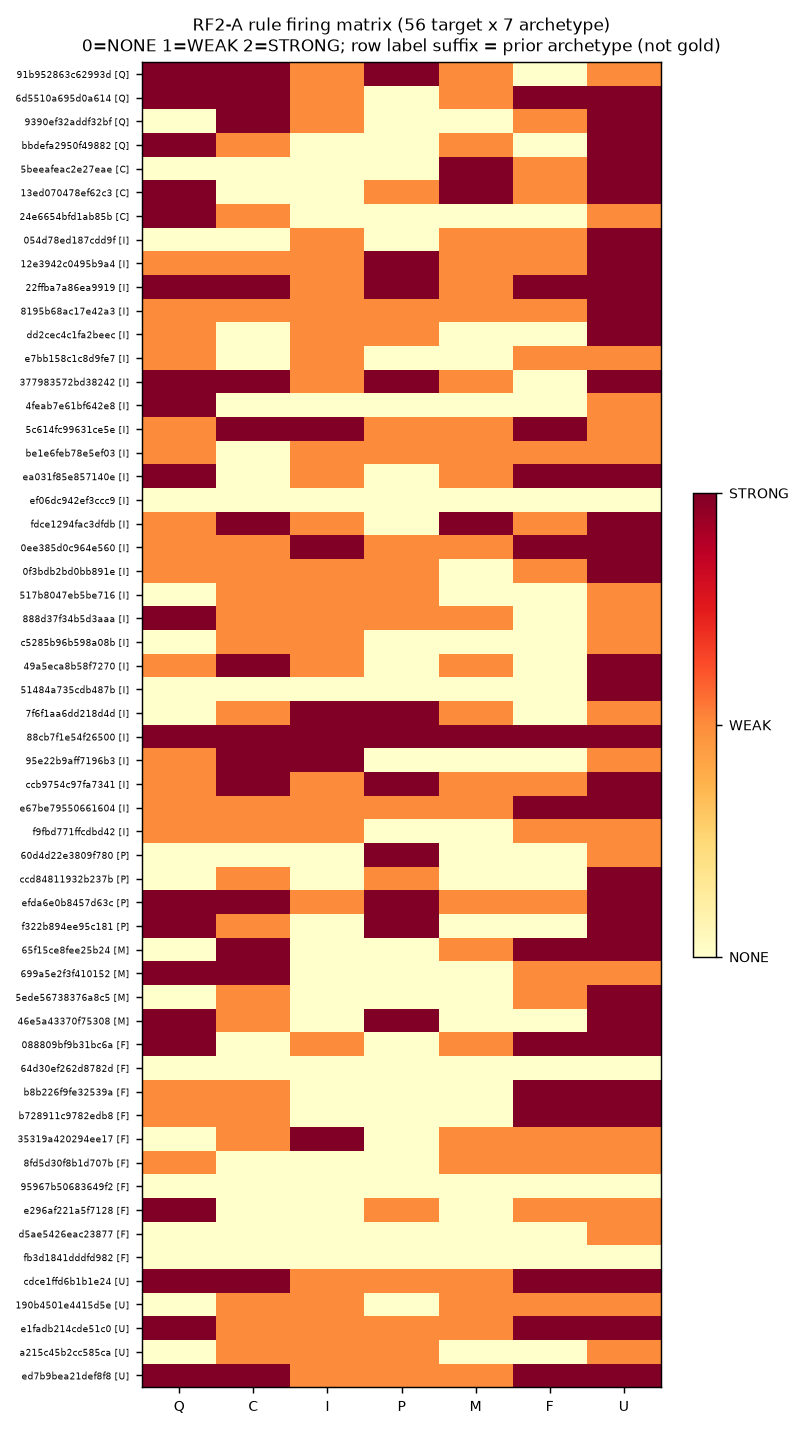

In [3]:
fm = pd.DataFrame(D["firing_matrix"]).T[A]
fm.columns = [S[a] for a in A]
fm.insert(0, "prior", [D["per_target"][w]["prior_archetype"] for w in fm.index])
fm.insert(1, "dom_dead", [D["per_target"][w]["dom_dead"] for w in fm.index])
display(fm.head(15))
print("... 총", len(fm), "행")
display(Image(str(RD / "figures" / "RF2_A_firing_heatmap.png")))

## 3. candidate-count 분포 (분모 N=56)

후보 수,0,1,2,3,4,5,6,7
STRONG,13,13,11,12,5,1,0,1
WEAK+,4,2,2,5,16,8,7,12


평균 STRONG 후보/target = 1.8393  | 평균 WEAK+ 후보/target = 4.4821


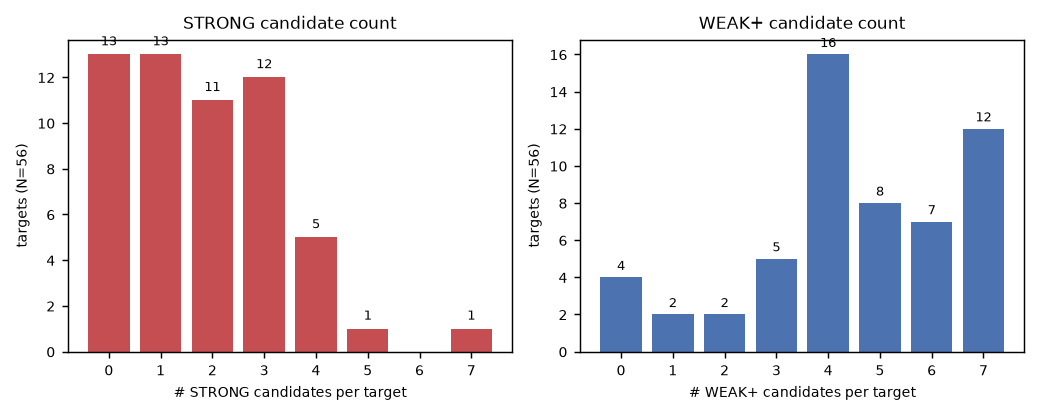

In [4]:
cd = D["candidate_count_distribution"]
dist = pd.DataFrame({
    "STRONG": pd.Series({int(k): v for k, v in cd["strong"].items()}),
    "WEAK+":  pd.Series({int(k): v for k, v in cd["weakplus"].items()}),
}).reindex(range(8)).fillna(0).astype(int)
dist.index.name = "후보 수"
display(dist.T)
print("평균 STRONG 후보/target =", cd["strong_mean"], " | 평균 WEAK+ 후보/target =", cd["weakplus_mean"])
display(Image(str(RD / "figures" / "RF2_A_candidate_distribution.png")))

## 4. no-evidence / single / multi (분모 명시)

In [5]:
rows = []
for lvl, key in (("STRONG", "strong_level"), ("WEAK+", "weakplus_level")):
    for b, v in D["evidence_buckets"][key].items():
        rows.append({"level": lvl, "bucket": b, "n": v["n"], "denominator": v["denominator"],
                     "rate": v["rate"], "wilson95_lo": v["wilson95"][0], "wilson95_hi": v["wilson95"][1]})
display(pd.DataFrame(rows))
display(Markdown("**SSOT §6 resolver 대입**: 유일 후보 → RULE 확정 "
    f"{D['evidence_buckets']['strong_level']['single_candidate']['n']}건 · "
    f"두 개 이상 강후보 → NLP fallback {D['evidence_buckets']['strong_level']['multi_candidate']['n']}건 · "
    f"evidence 없음 → AMBIGUOUS_UNRESOLVED {D['evidence_buckets']['strong_level']['no_evidence']['n']}건"))

,level,bucket,n,denominator,rate,wilson95_lo,wilson95_hi
0,STRONG,no_evidence,13,56,0.2321,0.1410,0.3577
1,STRONG,single_candidate,13,56,0.2321,0.1410,0.3577
2,STRONG,multi_candidate,30,56,0.5357,0.4070,0.6598
3,WEAK+,no_evidence,4,56,0.0714,0.0281,0.1698
4,WEAK+,single_candidate,2,56,0.0357,0.0098,0.1212
5,WEAK+,multi_candidate,50,56,0.8929,0.7853,0.9500


**SSOT §6 resolver 대입**: 유일 후보 → RULE 확정 13건 · 두 개 이상 강후보 → NLP fallback 30건 · evidence 없음 → AMBIGUOUS_UNRESOLVED 13건

## 5. 7x7 co-occurrence + overlap network

**STRONG 동시발화 (대각=marginal, 분모 N=56)**

,Q,C,I,P,M,F,U
Q,20,9,1,7,2,8,14
C,9,16,3,6,2,7,12
I,1,3,6,2,1,3,2
P,7,6,2,11,1,2,8
M,2,2,1,1,4,1,4
F,8,7,3,2,1,14,13
U,14,12,2,8,4,13,32


**WEAKPLUS 동시발화 (대각=marginal, 분모 N=56)**

,Q,C,I,P,M,F,U
Q,37,28,26,22,24,26,37
C,28,38,28,22,23,24,38
I,26,28,34,21,25,24,34
P,22,22,21,27,18,16,27
M,24,23,25,18,30,24,30
F,26,24,24,16,24,33,33
U,37,38,34,27,30,33,52


**WEAK+ pair 표 (Jaccard 내림차순)**

,pair,both_n,a_n,b_n,union_n,jaccard,rate_of_N,list_family_pair
0,C-U,38,38,52,52,0.7308,0.6786,False
1,Q-U,37,37,52,52,0.7115,0.6607,False
2,I-U,34,34,52,52,0.6538,0.6071,False
3,I-M,25,34,30,39,0.6410,0.4464,True
4,C-I,28,38,34,44,0.6364,0.5000,True
5,F-U,33,33,52,52,0.6346,0.5893,False
6,M-F,24,30,33,39,0.6154,0.4286,False
7,Q-C,28,37,38,47,0.5957,0.5000,False
8,Q-F,26,37,33,44,0.5909,0.4643,False
9,Q-I,26,37,34,45,0.5778,0.4643,False


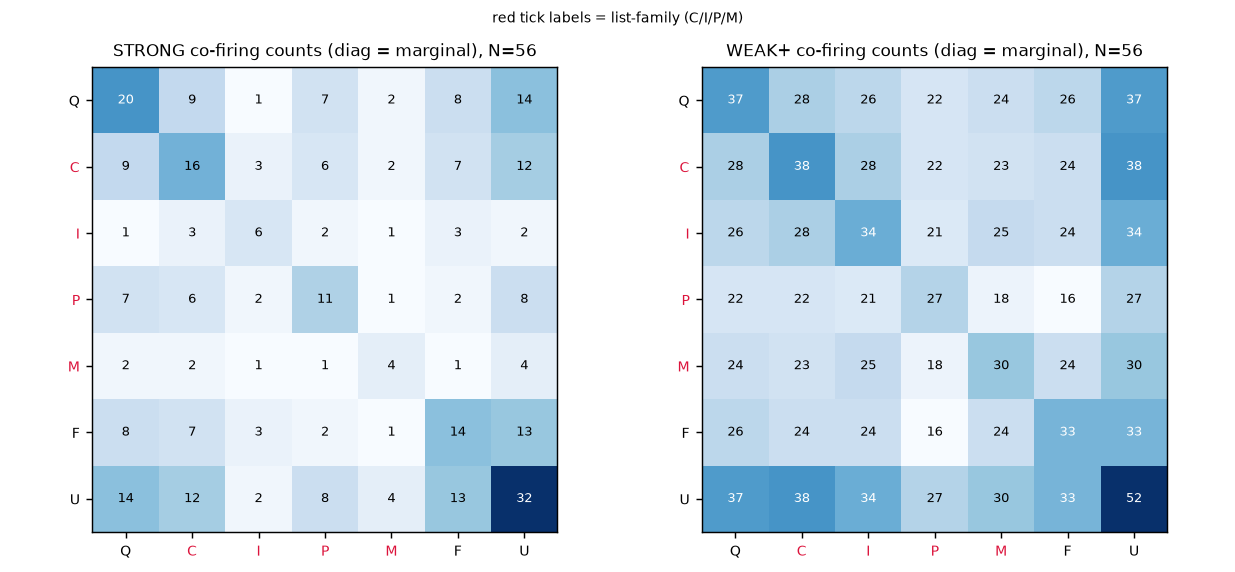

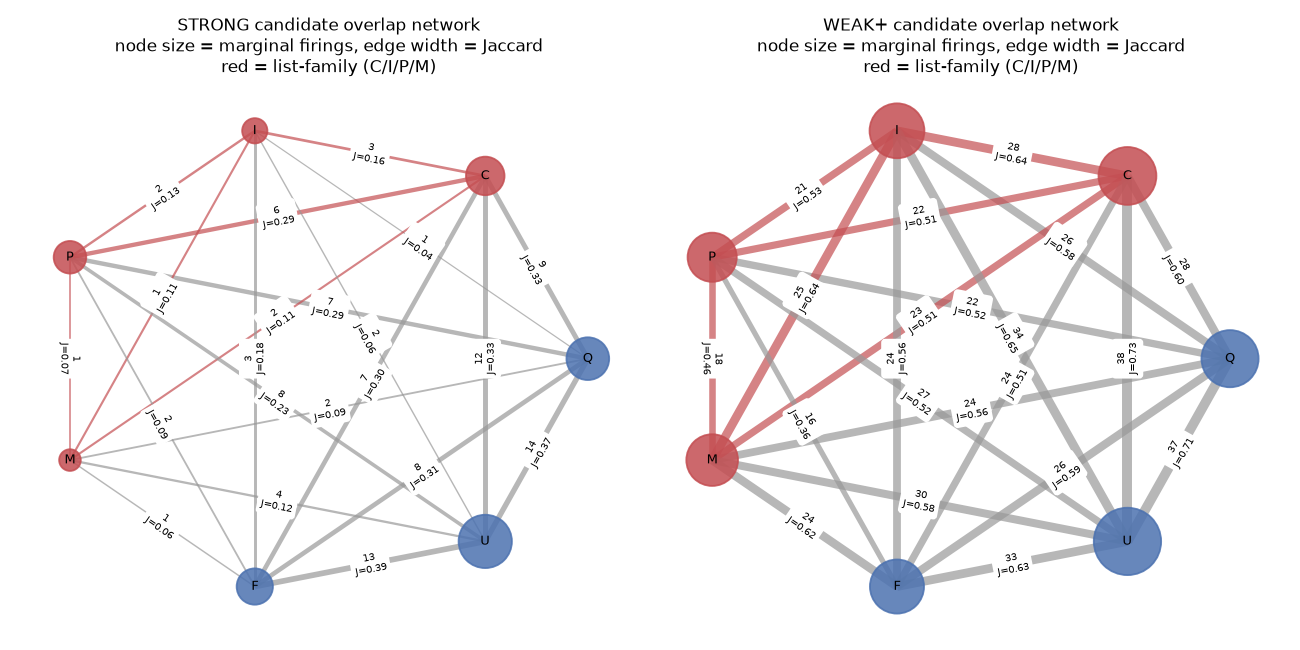

In [6]:
for lvl in ("strong", "weakplus"):
    C = pd.DataFrame(D["cooccurrence_matrix"][lvl], index=[S[a] for a in A], columns=[S[a] for a in A])
    display(Markdown(f"**{lvl.upper()} 동시발화 (대각=marginal, 분모 N={N})**"))
    display(C)
pairs = pd.DataFrame(D["cooccurrence_pairs"]["weakplus"])[
    ["pair","both_n","a_n","b_n","union_n","jaccard","rate_of_N","list_family_pair"]]
display(Markdown("**WEAK+ pair 표 (Jaccard 내림차순)**"))
display(pairs.sort_values("jaccard", ascending=False).reset_index(drop=True))
display(Image(str(RD / "figures" / "RF2_A_cooccurrence.png")))
display(Image(str(RD / "figures" / "RF2_A_overlap_network.png")))

## 6. H-A1 — list-family collapse 정량화

In [7]:
la = D["list_family_analysis"]
h1 = D["hypothesis_verdicts"]["H-A1_LIST_FAMILY_COLLAPSE"]
rows = []
for lvl in ("strong", "weakplus"):
    for grp in ("list_family_pairs", "control_pairs"):
        j = la[lvl][grp]["jaccard"]; cf = la[lvl][grp]["cofire_rate_of_N"]
        rows.append({"level": lvl, "group": grp, "n_pairs": j["n_pairs"],
                     "mean_jaccard": j["mean"], "median": j["median"],
                     "min": j["min"], "max": j["max"], "mean_cofire_rate_of_N": cf["mean"]})
display(pd.DataFrame(rows))
print("jaccard gap (family - control):  STRONG", la["jaccard_gap_strong"],
      " WEAK+", la["jaccard_gap_weakplus"])
print("기전(공유 card region) 충족:", h1["mechanism_criterion_met"], h1["mechanism_shared_card_region_hits"])
print("차별성 충족:", h1["differential_criterion_met"], "→ verdict:", h1["verdict"])
print()
print("[POST-HOC 기술 보조분석 — 사전등록 판정기준 아님]")
print(json.dumps({k: v for k, v in D["post_hoc_sensitivity"].items() if k != "hub_degree"},
                 ensure_ascii=False, indent=1))

,level,group,n_pairs,mean_jaccard,median,min,max,mean_cofire_rate_of_N
0,strong,list_family_pairs,6,0.1451,0.1222,0.0714,0.2857,0.0447
1,strong,control_pairs,15,0.2130,0.2286,0.0400,0.3939,0.1107
2,weakplus,list_family_pairs,6,0.5478,0.5183,0.4615,0.6410,0.4077
3,weakplus,control_pairs,15,0.5814,0.5778,0.3636,0.7308,0.4917


jaccard gap (family - control):  STRONG -0.0679  WEAK+ -0.0336
기전(공유 card region) 충족: True {'CONTENT_OPEN': 24, 'ITEM_DETAIL': 43, 'PLACE_LOOKUP': 25, 'COMMUNICATION_ENTRY': 29}
차별성 충족: False → verdict: PARTIALLY_SUPPORTED

[POST-HOC 기술 보조분석 — 사전등록 판정기준 아님]
{
 "label": "POST_HOC_DESCRIPTIVE — 사전등록 판정기준이 아니다",
 "hub_excluded": [
  "QUERY",
  "UTILITY_ENTRY"
 ],
 "strong": {
  "list_family_mean_jaccard": 0.1451,
  "control_no_hub_pairs": [
   "C-F",
   "I-F",
   "P-F",
   "M-F"
  ],
  "control_no_hub_mean_jaccard": 0.1566,
  "gap": -0.0116
 },
 "weakplus": {
  "list_family_mean_jaccard": 0.5478,
  "control_no_hub_pairs": [
   "C-F",
   "I-F",
   "P-F",
   "M-F"
  ],
  "control_no_hub_mean_jaccard": 0.5119,
  "gap": 0.0358
 }
}


## 7. H-A2 — UTILITY 특이도 / catch-all

In [8]:
h2 = D["hypothesis_verdicts"]["H-A2_UTILITY_CATCHALL"]
spec = pd.DataFrame({
    "fire_rate_STRONG": {S[a]: D["specificity"]["strong"]["per_archetype"][a]["fire_rate"] for a in A},
    "fire_rate_WEAK+":  {S[a]: D["specificity"]["weakplus"]["per_archetype"][a]["fire_rate"] for a in A},
    "sole_share_STRONG":{S[a]: D["specificity"]["strong"]["per_archetype"][a]["sole_share"] for a in A},
    "mean_cofired_STRONG":{S[a]: D["specificity"]["strong"]["per_archetype"][a]["mean_cofired"] for a in A},
    "exclusivity_WEAK+":{S[a]: D["shared_signal_profile"][a]["exclusivity"] for a in A},
})
display(spec)
print(json.dumps(D["utility_catchall"], ensure_ascii=False, indent=1))
print("희석형 기준:", h2["dilution_criterion_met"], "| 구제형 기준:", h2["rescue_criterion_met"],
      "→ verdict:", h2["verdict"])
print(h2["verdict_note"])

,fire_rate_STRONG,fire_rate_WEAK+,sole_share_STRONG,mean_cofired_STRONG,exclusivity_WEAK+
Q,0.3571,0.6607,0.2000,2.0500,0.0000
C,0.2857,0.6786,0.0000,2.4375,0.0000
I,0.1071,0.6071,0.1667,2.0000,0.0000
P,0.1964,0.4821,0.0909,2.3636,0.0000
M,0.0714,0.5357,0.0000,2.7500,0.0000
F,0.2500,0.5893,0.0000,2.4286,0.0000
U,0.5714,0.9286,0.2188,1.6562,0.0385


{
 "definition": "다른 6개 archetype 이 모두 non-STRONG 인 target 중 UTILITY 가 STRONG 인 비율 (= UTILITY 만 남는 구제 발화율)",
 "targets_with_no_other_strong": 20,
 "utility_strong_among_them": 7,
 "rescue_rate": 0.35,
 "wilson95": [
  0.1812,
  0.5671
 ],
 "utility_fire_rate_weakplus": 0.9286,
 "utility_fire_rate_strong": 0.5714
}
희석형 기준: False | 구제형 기준: True → verdict: PARTIALLY_SUPPORTED
UTILITY 는 '아무 데나 섞여 들어가 희석되는' 형태가 아니라 '가장 자주 켜지고, 다른 게 다 꺼졌을 때 유일하게 남는' 형태다. STRONG 단독발화 비율은 오히려 7개 중 최고이고, 다른 6개가 모두 non-STRONG 인 target 20건 중 7건에서 UTILITY 만 STRONG 이다.


## 8. H-A3 — no-evidence vs multi-candidate

In [9]:
h3 = D["hypothesis_verdicts"]["H-A3_NO_EVIDENCE_DOMINANT"]
print(json.dumps({k: v for k, v in h3.items() if k != "verdict_note"}, ensure_ascii=False, indent=1))
print()
print(h3["verdict_note"])
dead = [w for w, v in D["per_target"].items() if v["dom_dead"]]
print("\nDOM_DEAD (본문 200자 미만) target:", dead, "→ WEAK+ 무발화 4건과 동일 집합")

{
 "criterion": "STRONG 수준에서 no_evidence 비율 > multi_candidate 비율이면 지지.",
 "no_evidence_rate_strong": 0.2321,
 "multi_candidate_rate_strong": 0.5357,
 "no_evidence_rate_weakplus": 0.0714,
 "multi_candidate_rate_weakplus": 0.8929,
 "criterion_met_strong": false,
 "criterion_met_weakplus": false,
 "verdict": "REFUTED"
}

지배적 실패는 증거 부재가 아니라 다중후보다. 증거가 전혀 없는 target 은 WEAK+ 기준 4/56 이고 그 4건은 모두 DOM_DEAD(본문 텍스트 200자 미만)다. RF001-A 의 abstention 40/56 은 '증거 없음' 이 아니라 SSOT §6 resolver 가 다중 강후보를 강제매핑하지 않은 결과로 읽힌다.

DOM_DEAD (본문 200자 미만) target: ['64d30ef262d8782d', 'ef06dc942ef3ccc9', '95967b50683649f2', 'fb3d1841dddfd982'] → WEAK+ 무발화 4건과 동일 집합


## 9. archetype 별 shared-signal profile

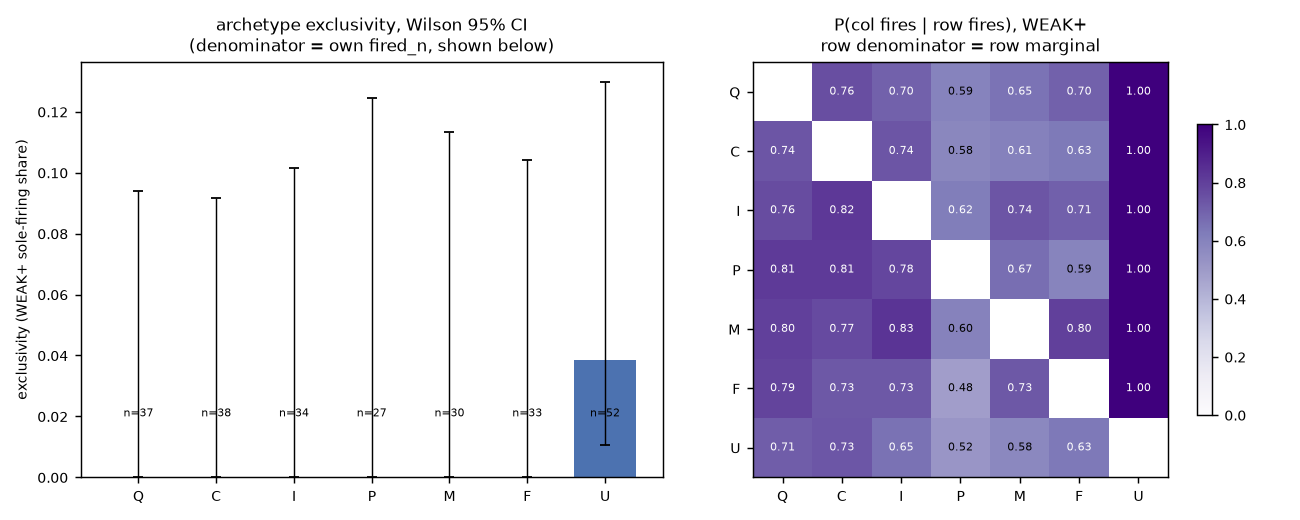

**Q QUERY** — WEAK+ 발화 37건, exclusivity 0.0 (Wilson [0.0, 0.0941])

,fired_target_n
endpoint:lex:search_submit@control,31
endpoint:form_or_input_present,29
region:lex:search@placeholder/input_name,18
region:search_inputs_n>=1,10
endpoint:url:search,1


**C CONTENT_OPEN** — WEAK+ 발화 38건, exclusivity 0.0 (Wilson [0.0, 0.0918])

,fired_target_n
region:card_repeat AND lex:content,24
endpoint:lex:media_play@control,23
endpoint:lex:media_play@nav,16
endpoint:article_present,7


**I ITEM_DETAIL** — WEAK+ 발화 34건, exclusivity 0.0 (Wilson [0.0, 0.1015])

...

**F FINANCIAL_ACTION_ENTRY** — WEAK+ 발화 33건, exclusivity 0.0 (Wilson [0.0, 0.1043])

,fired_target_n
region:lex:finance@control,24
region:lex:finance@nav,23
endpoint:lex:finance@nav AND lex:auth_gate@control,13
endpoint:url:finance,4
endpoint:password_gate_reached,3


**U UTILITY_ENTRY** — WEAK+ 발화 52건, exclusivity 0.0385 (Wilson [0.0106, 0.1298])

,fired_target_n
endpoint:n_primary_action_candidates>=1,52
region:lex:utility@control,29
region:lex:utility@nav,18


문자열까지 두 archetype 이 공유하는 신호:
{
 "password_gate_reached": [
  "COMMUNICATION_ENTRY",
  "FINANCIAL_ACTION_ENTRY"
 ]
}


In [10]:
display(Image(str(RD / "figures" / "RF2_A_shared_signal_profile.png")))
for a in A:
    sp = D["shared_signal_profile"][a]
    display(Markdown(f"**{S[a]} {a}** — WEAK+ 발화 {sp['fired_n']}건, exclusivity "
                     f"{sp['exclusivity']} (Wilson {sp['wilson95_exclusivity']})"))
    display(pd.Series(sp["top_signals"], name="fired_target_n").to_frame())
print("문자열까지 두 archetype 이 공유하는 신호:")
print(json.dumps(D["structurally_shared_signals"], ensure_ascii=False, indent=1))

## 10. prior_agreement (accuracy 아님)

In [11]:
pa = D["prior_agreement"]
print(pa["note"])
display(pd.DataFrame({k: v for k, v in pa.items() if k not in ("note", "per_prior_class")}).T)
pc = pd.DataFrame(pa["per_prior_class"]).T
pc["wilson95"] = pc["wilson95"].astype(str)
display(pc)
display(Markdown("> n<=5 인 prior class 가 5개다 (UTILITY 5 / COMMUNICATION 4 / PLACE 4 / "
                 "QUERY 4 / CONTENT 3). Wilson CI 폭 때문에 class 간 순위 비교는 하지 않는다."))

prior_archetype 은 gold label 이 아니라 business-domain prior 다. 아래 지표는 accuracy 가 아니라 prior_agreement 다.


,n,denominator,rate,wilson95
prior_in_strong_set,17,56,0.3036,"[0.199, 0.4334]"
prior_in_weakplus_set,43,56,0.7679,"[0.6423, 0.859]"
unique_strong_equals_prior,1,56,0.0179,"[0.0032, 0.0945]"


,n,prior_in_strong_set_n,rate,wilson95,mean_n_strong,mean_n_weakplus
COMMUNICATION_ENTRY,4,0,0.0,"[0.0, 0.4899]",2.25,3.75
CONTENT_OPEN,3,0,0.0,"[0.0, 0.5615]",2.0,3.6667
FINANCIAL_ACTION_ENTRY,10,3,0.3,"[0.1078, 0.6032]",0.9,2.7
ITEM_DETAIL,26,5,0.1923,"[0.0851, 0.3788]",1.8462,5.0769
PLACE_LOOKUP,4,3,0.75,"[0.3006, 0.9544]",2.25,4.0
QUERY,4,3,0.75,"[0.3006, 0.9544]",2.75,5.0
UTILITY_ENTRY,5,3,0.6,"[0.2307, 0.8824]",2.2,6.0


> n<=5 인 prior class 가 5개다 (UTILITY 5 / COMMUNICATION 4 / PLACE 4 / QUERY 4 / CONTENT 3). Wilson CI 폭 때문에 class 간 순위 비교는 하지 않는다.

## 11. 결론

- 상위 가설 **SUPPORTED** — 결정적 증거는 archetype 을 유일하게 지목하지 못한다.
- **H-A1 PARTIALLY_SUPPORTED** — 공유 card 신호라는 기전은 실재하나, C/I/P/M 이 서로 **특히** 안
  나뉜다는 차별적 주장은 성립하지 않는다. 비분리성은 7개 전체의 전역 문제다.
- **H-A2 PARTIALLY_SUPPORTED** — UTILITY 는 catch-all 이되 "무차별 희석형" 이 아니라
  **"최후 잔존형(residual)"** 이다.
- **H-A3 REFUTED** — 지배적 실패는 증거 부재가 아니라 **다중후보**다.

전문·반례·limitation·production implication 은 `results/RF2_A_FINDINGS.md`.
